# Euclid's Elements - Book I: Plane Geometry

## My Study Notes

Working through Euclid's Elements, the foundational text of geometry. The beauty of Euclid is that everything is constructed using only:

- **A straightedge** - to draw a line between any two points
- **A compass** - to draw a circle with a given center and radius

That's it. No rulers with measurements. No picking up the compass and moving it somewhere else while keeping the same width. Just these two tools and pure logic.

---

## The Postulates (What We're Allowed to Do)

1. Draw a straight line from any point to any point
2. Extend a finite straight line continuously in a straight line  
3. Describe a circle with any center and radius
4. All right angles are equal to one another
5. (The parallel postulate - we'll get to this later)

## Key Axioms (Common Notions)

1. Things equal to the same thing are equal to each other
2. If equals are added to equals, the wholes are equal
3. If equals are subtracted from equals, the remainders are equal
4. Things which coincide with one another are equal
5. The whole is greater than the part

In [2]:
!pip install numpy matplotlib


[notice] A new release of pip is available: 23.2.1 -> 26.1.2
[notice] To update, run: C:\Users\motsepeh\AppData\Local\Programs\Python\Python312\python.exe -m pip install --upgrade pip


In [3]:
# Setup for visualizations
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, Arc, FancyArrowPatch
from matplotlib.lines import Line2D

%matplotlib inline
plt.rcParams['figure.figsize'] = [10, 8]
plt.rcParams['font.size'] = 12

def draw_circle(ax, center, radius, color='blue', linestyle='-', alpha=0.3, fill=False):
    """Draw a circle on the given axes"""
    circle = Circle(center, radius, fill=fill, color=color, linestyle=linestyle, alpha=alpha, linewidth=2)
    ax.add_patch(circle)
    return circle

def draw_line(ax, p1, p2, color='black', linewidth=2, linestyle='-'):
    """Draw a line segment between two points"""
    ax.plot([p1[0], p2[0]], [p1[1], p2[1]], color=color, linewidth=linewidth, linestyle=linestyle)

def draw_point(ax, p, label=None, color='black', size=80):
    """Draw a point with optional label"""
    ax.scatter(*p, color=color, s=size, zorder=5)
    if label:
        ax.annotate(label, p, xytext=(5, 5), textcoords='offset points', fontsize=12, fontweight='bold')

---

## Proposition I - Constructing an Equilateral Triangle

**Problem:** Given a line segment AB, construct an equilateral triangle on it.

### The Intuition

I have a line segment AB. I want to build a triangle where all three sides are equal. But I only have a compass and straightedge - no ruler to measure anything.

The key insight: **A circle is a "distance enforcer."** Every point on a circle is exactly the same distance from the center. So if I want to find a point that's distance AB from both A and B, I need to find where two circles intersect:

1. Circle centered at A with radius AB - every point on this circle is distance AB from A
2. Circle centered at B with radius BA - every point on this circle is distance AB from B

Where they intersect, that point C is equidistant from both A and B, and that distance is exactly AB.

### The Construction

1. Draw circle centered at A with radius AB
2. Draw circle centered at B with radius BA  
3. The circles intersect at point C
4. Connect A to C and B to C
5. Triangle ABC is equilateral

### Why It Works

- AC = AB (because C is on the circle centered at A)
- BC = BA (because C is on the circle centered at B)
- Therefore AC = AB = BC - all three sides are equal

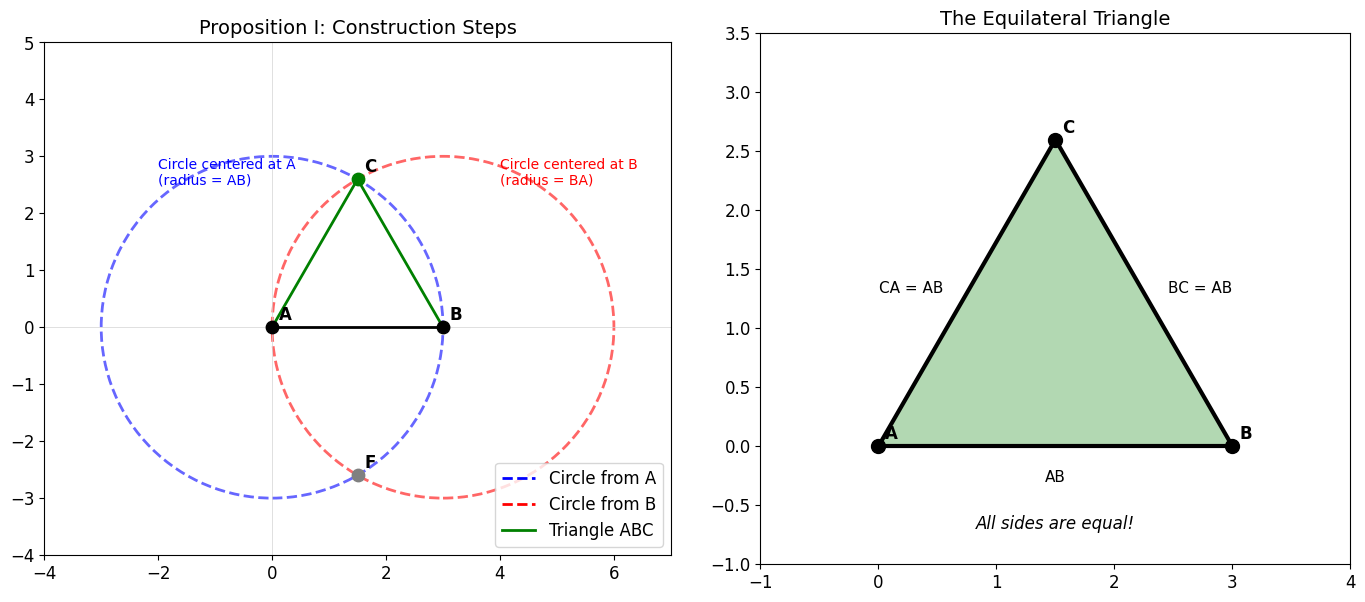

Proposition I Complete:
  AB = 3.00
  BC = 3.00
  CA = 3.00
  All three sides are equal - equilateral triangle constructed.


In [4]:
# Proposition I: Constructing an Equilateral Triangle

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Points A and B
A = np.array([0, 0])
B = np.array([3, 0])
radius = np.linalg.norm(B - A)  # Length AB

# Find intersection point C (above the line)
# Using the formula for circle intersection
d = radius  # distance between centers = AB
# For two circles of same radius intersecting, the intersection height is:
h = np.sqrt(radius**2 - (d/2)**2)
C = np.array([(A[0] + B[0])/2, h])

# Also find the lower intersection F
F = np.array([(A[0] + B[0])/2, -h])

# LEFT PLOT: Step-by-step construction
ax1 = axes[0]
ax1.set_aspect('equal')
ax1.set_xlim(-4, 7)
ax1.set_ylim(-4, 5)
ax1.set_title('Proposition I: Construction Steps', fontsize=14)
ax1.axhline(y=0, color='lightgray', linewidth=0.5)
ax1.axvline(x=0, color='lightgray', linewidth=0.5)

# Draw the circles
circle1 = Circle(A, radius, fill=False, color='blue', linestyle='--', alpha=0.6, linewidth=2)
circle2 = Circle(B, radius, fill=False, color='red', linestyle='--', alpha=0.6, linewidth=2)
ax1.add_patch(circle1)
ax1.add_patch(circle2)

# Draw line AB
draw_line(ax1, A, B, color='black', linewidth=2)

# Draw the triangle
draw_line(ax1, A, C, color='green', linewidth=2)
draw_line(ax1, B, C, color='green', linewidth=2)

# Draw points
draw_point(ax1, A, 'A')
draw_point(ax1, B, 'B')
draw_point(ax1, C, 'C', color='green')
draw_point(ax1, F, 'F', color='gray')

# Labels
ax1.text(-2, 2.5, 'Circle centered at A\n(radius = AB)', color='blue', fontsize=10)
ax1.text(4, 2.5, 'Circle centered at B\n(radius = BA)', color='red', fontsize=10)

# Legend
ax1.plot([], [], 'b--', linewidth=2, label='Circle from A')
ax1.plot([], [], 'r--', linewidth=2, label='Circle from B')
ax1.plot([], [], 'g-', linewidth=2, label='Triangle ABC')
ax1.legend(loc='lower right')

# RIGHT PLOT: Final result with annotations
ax2 = axes[1]
ax2.set_aspect('equal')
ax2.set_xlim(-1, 4)
ax2.set_ylim(-1, 3.5)
ax2.set_title('The Equilateral Triangle', fontsize=14)

# Draw the triangle
draw_line(ax2, A, B, color='black', linewidth=3)
draw_line(ax2, B, C, color='black', linewidth=3)
draw_line(ax2, C, A, color='black', linewidth=3)

# Fill the triangle
triangle = plt.Polygon([A, B, C], alpha=0.3, color='green')
ax2.add_patch(triangle)

# Draw points
draw_point(ax2, A, 'A', size=100)
draw_point(ax2, B, 'B', size=100)
draw_point(ax2, C, 'C', size=100)

# Label the sides
mid_AB = (A + B) / 2
mid_BC = (B + C) / 2
mid_CA = (C + A) / 2
ax2.text(mid_AB[0], mid_AB[1] - 0.3, 'AB', fontsize=11, ha='center')
ax2.text(mid_BC[0] + 0.2, mid_BC[1], 'BC = AB', fontsize=11, ha='left')
ax2.text(mid_CA[0] - 0.2, mid_CA[1], 'CA = AB', fontsize=11, ha='right')

ax2.text(1.5, -0.7, 'All sides are equal!', fontsize=12, ha='center', style='italic')

plt.tight_layout()
plt.show()

print("Proposition I Complete:")
print(f"  AB = {radius:.2f}")
print(f"  BC = {np.linalg.norm(C - B):.2f}")
print(f"  CA = {np.linalg.norm(A - C):.2f}")
print("  All three sides are equal - equilateral triangle constructed.")

---

## Proposition II - Copying a Line Segment to a New Point

**Problem:** Given a point A and a line segment BC somewhere else, draw a line from A that is exactly the same length as BC.

### Why Is This Even a Problem?

This seems trivial with a modern compass - just open it to length BC, pick it up, put it at A, done.

But Euclid's compass is a "collapsing compass." The moment you lift it off the paper, it snaps shut. You can't just transfer a distance directly.

So Euclid invents a clever **"distance teleportation machine"** using circles.

### The Core Insight

A circle is a **distance copier**. If I draw a circle with radius BC, anywhere the circle touches is *exactly* distance BC from the center.

Euclid uses this fact twice to relay the distance from BC to point A through a chain of equal lengths.

### The Construction (Step by Step)

1. **Join A to B** - Draw line segment AB
2. **Build an equilateral triangle ABD on AB** - Using Proposition I
3. **Draw a circle centered at B with radius BC** - This circle passes through C
4. **Extend DB to meet this circle at E** - So now BE = BC
5. **Draw a circle centered at D with radius DE**
6. **Extend DA to meet this circle at F** - So DF = DE

Now here's the magic: AF = BC

### The Relay Chain (Why It Works)

Think of it like passing water through bowls when you can't pick up the cup:

```
BC → BE → DE → DF → (DF - DB) = AF
```

- In the equilateral triangle: DA = DB
- From the first circle: BE = BC
- So DE = DB + BE = DB + BC
- From the second circle: DF = DE = DB + BC
- Therefore: AF = DF - DA = (DB + BC) - DB = BC

The equilateral triangle and circles are just scaffolding. The only thing that matters is the final result: **AF = BC**

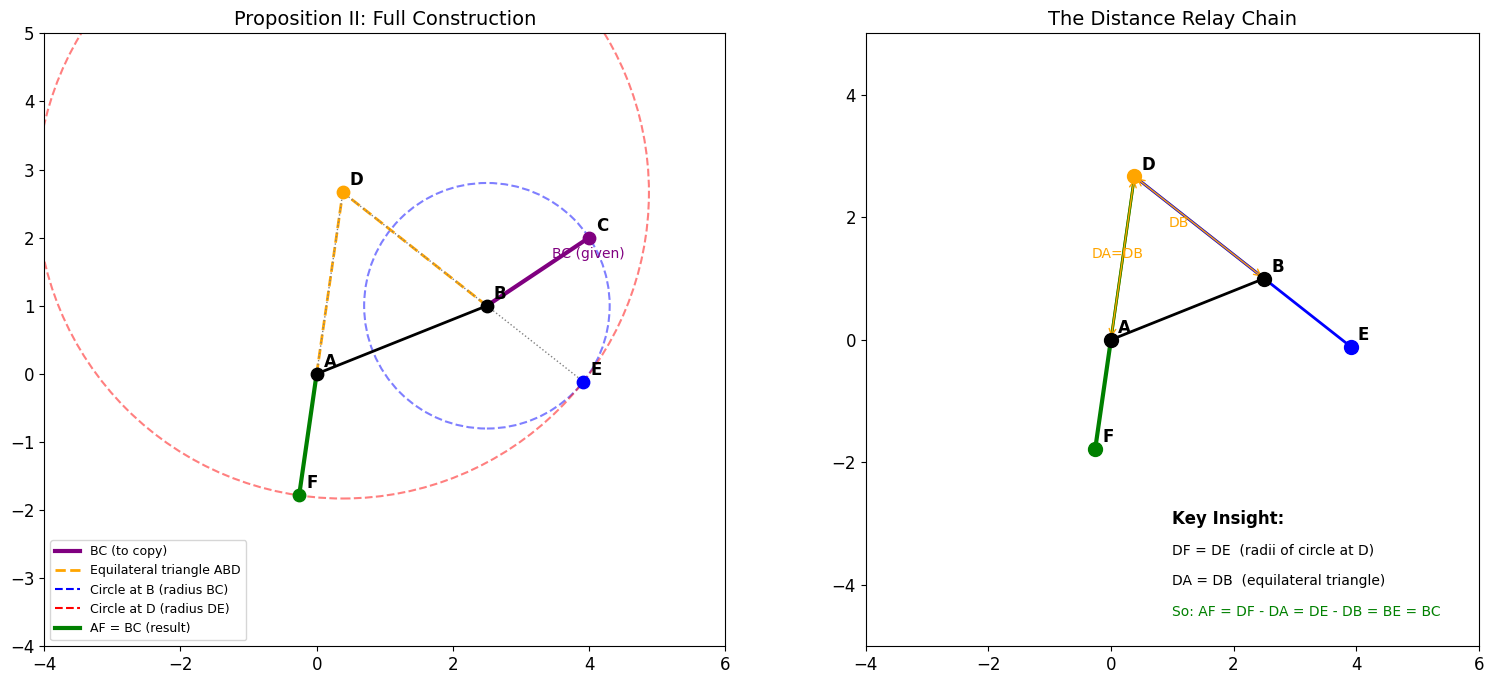


Proposition II - Verification:
  Original segment BC = 1.8028
  Constructed segment AF = 1.8028
  AF = BC? True


In [5]:
# Proposition II: Copying a Line Segment to a New Point

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Given: Point A and segment BC
A = np.array([0, 0])
B = np.array([2.5, 1])
C = np.array([4, 2])  # BC is the segment to copy

# Length of BC
BC_length = np.linalg.norm(C - B)

# Step 1: Build equilateral triangle ABD on AB
AB_length = np.linalg.norm(B - A)
# Find D (apex of equilateral triangle above AB)
AB_mid = (A + B) / 2
AB_perp = np.array([-(B-A)[1], (B-A)[0]])  # perpendicular to AB
AB_perp = AB_perp / np.linalg.norm(AB_perp)
h_ABD = np.sqrt(AB_length**2 - (AB_length/2)**2)
D = AB_mid + h_ABD * AB_perp

# Step 2: Circle centered at B with radius BC, find E on extension of DB
DB_dir = (B - D) / np.linalg.norm(B - D)
E = B + BC_length * DB_dir  # E is on circle, along DB extended

# Step 3: Circle centered at D with radius DE, find F on extension of DA
DE_length = np.linalg.norm(E - D)
DA_dir = (A - D) / np.linalg.norm(A - D)
F = D + DE_length * DA_dir  # F is on circle, along DA extended

# LEFT PLOT: Full construction
ax1 = axes[0]
ax1.set_aspect('equal')
ax1.set_title('Proposition II: Full Construction', fontsize=14)

# Draw the given segment BC
draw_line(ax1, B, C, color='purple', linewidth=3)
ax1.text((B[0]+C[0])/2 + 0.2, (B[1]+C[1])/2 + 0.2, 'BC (given)', color='purple', fontsize=10)

# Draw line AB
draw_line(ax1, A, B, color='black', linewidth=2)

# Draw equilateral triangle ABD
draw_line(ax1, A, D, color='orange', linewidth=2, linestyle='--')
draw_line(ax1, B, D, color='orange', linewidth=2, linestyle='--')

# Draw circle centered at B with radius BC
circle_B = Circle(B, BC_length, fill=False, color='blue', linestyle='--', alpha=0.5, linewidth=1.5)
ax1.add_patch(circle_B)

# Extend DB to E
draw_line(ax1, D, E, color='gray', linewidth=1, linestyle=':')

# Draw circle centered at D with radius DE
circle_D = Circle(D, DE_length, fill=False, color='red', linestyle='--', alpha=0.5, linewidth=1.5)
ax1.add_patch(circle_D)

# Extend DA to F
draw_line(ax1, D, F, color='gray', linewidth=1, linestyle=':')

# The result: AF
draw_line(ax1, A, F, color='green', linewidth=3)

# Draw all points
draw_point(ax1, A, 'A')
draw_point(ax1, B, 'B')
draw_point(ax1, C, 'C', color='purple')
draw_point(ax1, D, 'D', color='orange')
draw_point(ax1, E, 'E', color='blue')
draw_point(ax1, F, 'F', color='green')

ax1.set_xlim(-4, 6)
ax1.set_ylim(-4, 5)

# Legend
ax1.plot([], [], 'purple', linewidth=3, label='BC (to copy)')
ax1.plot([], [], 'orange', linewidth=2, linestyle='--', label='Equilateral triangle ABD')
ax1.plot([], [], 'b--', linewidth=1.5, label='Circle at B (radius BC)')
ax1.plot([], [], 'r--', linewidth=1.5, label='Circle at D (radius DE)')
ax1.plot([], [], 'green', linewidth=3, label='AF = BC (result)')
ax1.legend(loc='lower left', fontsize=9)

# RIGHT PLOT: The distance relay chain
ax2 = axes[1]
ax2.set_aspect('equal')
ax2.set_title('The Distance Relay Chain', fontsize=14)

# Simplified view showing the key relationships
# Draw the triangle
draw_line(ax2, A, B, color='black', linewidth=2)
draw_line(ax2, A, D, color='orange', linewidth=2)
draw_line(ax2, B, D, color='orange', linewidth=2)

# Draw the chain: D -> B -> E
draw_line(ax2, D, B, color='blue', linewidth=2)
draw_line(ax2, B, E, color='blue', linewidth=2)

# Draw the result: D -> A -> F
draw_line(ax2, D, A, color='green', linewidth=2)
draw_line(ax2, A, F, color='green', linewidth=3)

# Points
draw_point(ax2, A, 'A', size=100)
draw_point(ax2, B, 'B', size=100)
draw_point(ax2, D, 'D', color='orange', size=100)
draw_point(ax2, E, 'E', color='blue', size=100)
draw_point(ax2, F, 'F', color='green', size=100)

# Annotations showing equalities
ax2.annotate('', xy=B, xytext=D, arrowprops=dict(arrowstyle='<->', color='orange'))
ax2.text((D[0]+B[0])/2 - 0.5, (D[1]+B[1])/2, 'DB', fontsize=10, color='orange')

ax2.annotate('', xy=A, xytext=D, arrowprops=dict(arrowstyle='<->', color='orange'))
ax2.text((D[0]+A[0])/2 - 0.5, (D[1]+A[1])/2, 'DA=DB', fontsize=10, color='orange')

ax2.text(1, -3, 'Key Insight:', fontsize=12, fontweight='bold')
ax2.text(1, -3.5, 'DF = DE  (radii of circle at D)', fontsize=10)
ax2.text(1, -4, 'DA = DB  (equilateral triangle)', fontsize=10)
ax2.text(1, -4.5, 'So: AF = DF - DA = DE - DB = BE = BC', fontsize=10, color='green')

ax2.set_xlim(-4, 6)
ax2.set_ylim(-5, 5)

plt.tight_layout()
plt.show()

print("\nProposition II - Verification:")
print(f"  Original segment BC = {BC_length:.4f}")
print(f"  Constructed segment AF = {np.linalg.norm(F - A):.4f}")
print(f"  AF = BC? {np.isclose(np.linalg.norm(F - A), BC_length)}")

### My Own Construction for Proposition II

I worked through this myself and here's how I built AD = C:

1. First I drew a line from the endpoint of C to point A
2. Then I built an equilateral triangle with CA as the base, creating a new vertex F
3. I drew a big circle centered at F
4. Extended the line through F and C's endpoint to hit the circle at point E
5. Then extended the line through F and A to hit the circle at point G

The key realization: **A→G equals C** because of the relay through the equilateral triangle and circles.

This is exactly what Euclid does, just with my own labeling. The equilateral triangle is scaffolding, the circles are distance copiers, and the final segment is what we wanted all along.

---

## Proposition III - Cutting Off a Segment Equal to a Shorter One

**Problem:** Given two line segments where AB is longer than C, cut off a piece from AB that equals C.

### The Setup

- AB is the longer segment (the "rope")
- C is the shorter segment (the "measuring stick")
- I want to mark a point E on AB such that AE = C

### The Intuition

I can't directly measure C onto AB. But I *can*:
1. Use Proposition II to copy segment C to start at point A, creating segment AD = C
2. Then use a circle centered at A with radius AD to "swing" that distance onto AB

Wherever the circle intersects AB, that's my point E, and AE = AD = C.

### The Construction

1. **Use Prop II to construct AD = C** starting at point A
   - This is where all the equilateral triangle + two circles machinery happens
   - The end result: I have a segment AD with length equal to C

2. **Draw a circle centered at A with radius AD**
   - This circle hits AB at some point E

3. **AE = AD = C** because:
   - AE = AD (both are radii of the same circle)
   - AD = C (by construction using Prop II)
   - Things equal to the same thing are equal to each other

### Prop III Uses Prop II, and Prop II Uses Prop I

This is beautiful - the propositions build on each other:

```
Prop I: Construct equilateral triangle
    ↓
Prop II: Copy a segment to a new point (uses Prop I)
    ↓
Prop III: Cut off a segment (uses Prop II)
```

Each construction is a tool that gets used in the next one.

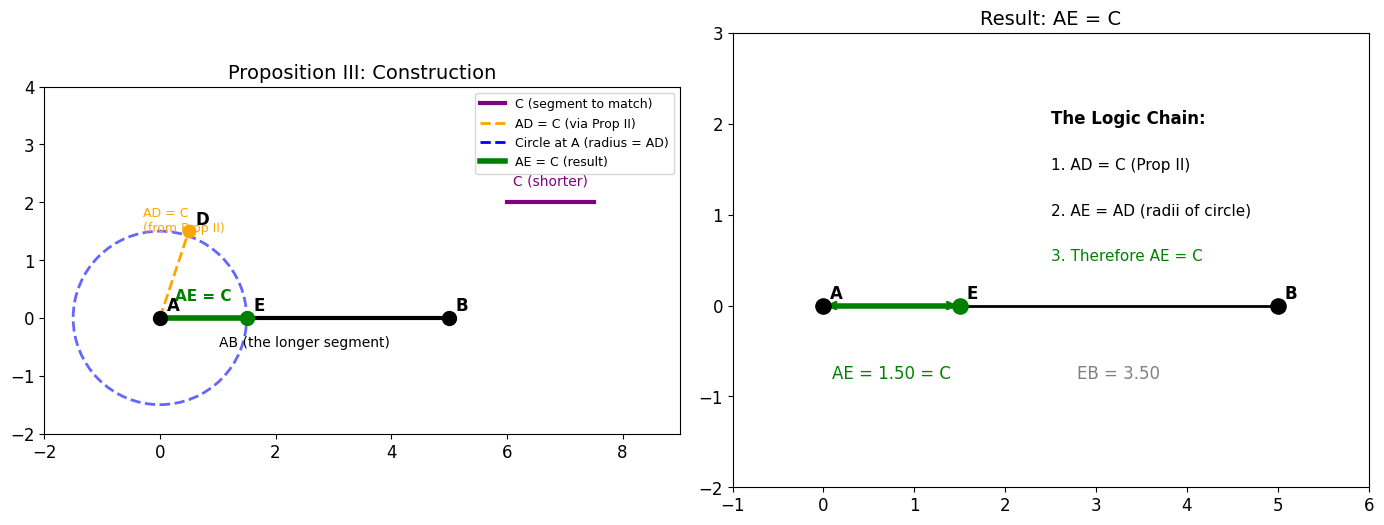


Proposition III - Verification:
  Segment C has length: 1.5000
  Segment AB has length: 5.0000
  Cut-off segment AE has length: 1.5000
  AE = C? True


In [6]:
# Proposition III: Cutting Off a Segment Equal to a Shorter One

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Given: Long segment AB and short segment C
A = np.array([0, 0])
B = np.array([5, 0])
AB_length = np.linalg.norm(B - A)

# Segment C (somewhere else, shorter)
C_start = np.array([6, 2])
C_end = np.array([7.5, 2])
C_length = np.linalg.norm(C_end - C_start)

# Using Prop II, we construct AD = C starting at A
# For visualization, let's just place D along some direction from A
D = A + np.array([0.5, C_length])  # AD has length C

# Circle centered at A with radius AD = C
# This intersects AB at point E
E = A + C_length * (B - A) / np.linalg.norm(B - A)  # E is on AB at distance C from A

# LEFT PLOT: The construction
ax1 = axes[0]
ax1.set_aspect('equal')
ax1.set_title('Proposition III: Construction', fontsize=14)

# Draw the given segment AB
draw_line(ax1, A, B, color='black', linewidth=3)
ax1.text((A[0]+B[0])/2, -0.5, 'AB (the longer segment)', ha='center', fontsize=10)

# Draw the given segment C (separately)
draw_line(ax1, C_start, C_end, color='purple', linewidth=3)
ax1.text((C_start[0]+C_end[0])/2, C_start[1] + 0.3, 'C (shorter)', ha='center', color='purple', fontsize=10)

# Draw AD = C (result of Prop II, shown as dashed)
draw_line(ax1, A, D, color='orange', linewidth=2, linestyle='--')
ax1.text(D[0] - 0.8, D[1], 'AD = C\n(from Prop II)', fontsize=9, color='orange')

# Draw circle centered at A with radius AD
circle_A = Circle(A, C_length, fill=False, color='blue', linestyle='--', alpha=0.6, linewidth=2)
ax1.add_patch(circle_A)

# Draw AE (the result)
draw_line(ax1, A, E, color='green', linewidth=4)
ax1.text((A[0]+E[0])/2, 0.3, 'AE = C', ha='center', color='green', fontsize=11, fontweight='bold')

# Points
draw_point(ax1, A, 'A', size=100)
draw_point(ax1, B, 'B', size=100)
draw_point(ax1, D, 'D', color='orange', size=80)
draw_point(ax1, E, 'E', color='green', size=100)

ax1.set_xlim(-2, 9)
ax1.set_ylim(-2, 4)

# Legend
ax1.plot([], [], 'purple', linewidth=3, label='C (segment to match)')
ax1.plot([], [], 'orange', linewidth=2, linestyle='--', label='AD = C (via Prop II)')
ax1.plot([], [], 'b--', linewidth=2, label='Circle at A (radius = AD)')
ax1.plot([], [], 'green', linewidth=4, label='AE = C (result)')
ax1.legend(loc='upper right', fontsize=9)

# RIGHT PLOT: Summary diagram
ax2 = axes[1]
ax2.set_aspect('equal')
ax2.set_title('Result: AE = C', fontsize=14)

# Just show AB with E marked
draw_line(ax2, A, B, color='black', linewidth=2)
draw_line(ax2, A, E, color='green', linewidth=4)

# Highlight the cut-off portion
ax2.annotate('', xy=E, xytext=A, 
             arrowprops=dict(arrowstyle='<->', color='green', lw=2))

# Points
draw_point(ax2, A, 'A', size=120)
draw_point(ax2, B, 'B', size=120)
draw_point(ax2, E, 'E', color='green', size=120)

# Annotations
ax2.text((A[0]+E[0])/2, -0.8, f'AE = {C_length:.2f} = C', ha='center', fontsize=12, color='green')
ax2.text((E[0]+B[0])/2, -0.8, f'EB = {np.linalg.norm(B-E):.2f}', ha='center', fontsize=12, color='gray')

ax2.text(2.5, 2, 'The Logic Chain:', fontsize=12, fontweight='bold')
ax2.text(2.5, 1.5, '1. AD = C (Prop II)', fontsize=11)
ax2.text(2.5, 1.0, '2. AE = AD (radii of circle)', fontsize=11)
ax2.text(2.5, 0.5, '3. Therefore AE = C', fontsize=11, color='green')

ax2.set_xlim(-1, 6)
ax2.set_ylim(-2, 3)

plt.tight_layout()
plt.show()

print("\nProposition III - Verification:")
print(f"  Segment C has length: {C_length:.4f}")
print(f"  Segment AB has length: {AB_length:.4f}")
print(f"  Cut-off segment AE has length: {np.linalg.norm(E - A):.4f}")
print(f"  AE = C? {np.isclose(np.linalg.norm(E - A), C_length)}")

---

## The Dependency Chain: Props I → II → III

One of the elegant things about Euclid is how each proposition builds on the previous ones. Let me visualize this:

```
PROPOSITION I                    PROPOSITION II                    PROPOSITION III
─────────────                    ──────────────                    ───────────────
Construct equilateral    →→→→    Copy segment BC         →→→→     Cut segment from AB
triangle on line AB              to start at point A              equal to segment C

Uses:                            Uses:                             Uses:
• Postulate III (circles)        • Prop I (eq. triangle)           • Prop II (copy segment)
• Postulate I (join points)      • Circles to relay distance       • Circle to transfer length
```

Each proposition gives us a new **tool** we can use in later constructions. Prop I gives us equilateral triangles. Prop II gives us distance copying. Prop III gives us distance marking.

---

## Key Takeaways from Props I-III

1. **Circles are distance enforcers** - Every point on a circle is exactly one radius from the center

2. **Equilateral triangles give us equal lengths** - Useful scaffolding for constructions

3. **The collapsing compass limitation** forces creative solutions - We can't just pick up a distance and move it

4. **Each proposition is a reusable tool** - Prop I is used inside Prop II, which is used inside Prop III

---

*Next up: Proposition IV - The Side-Angle-Side congruence theorem*

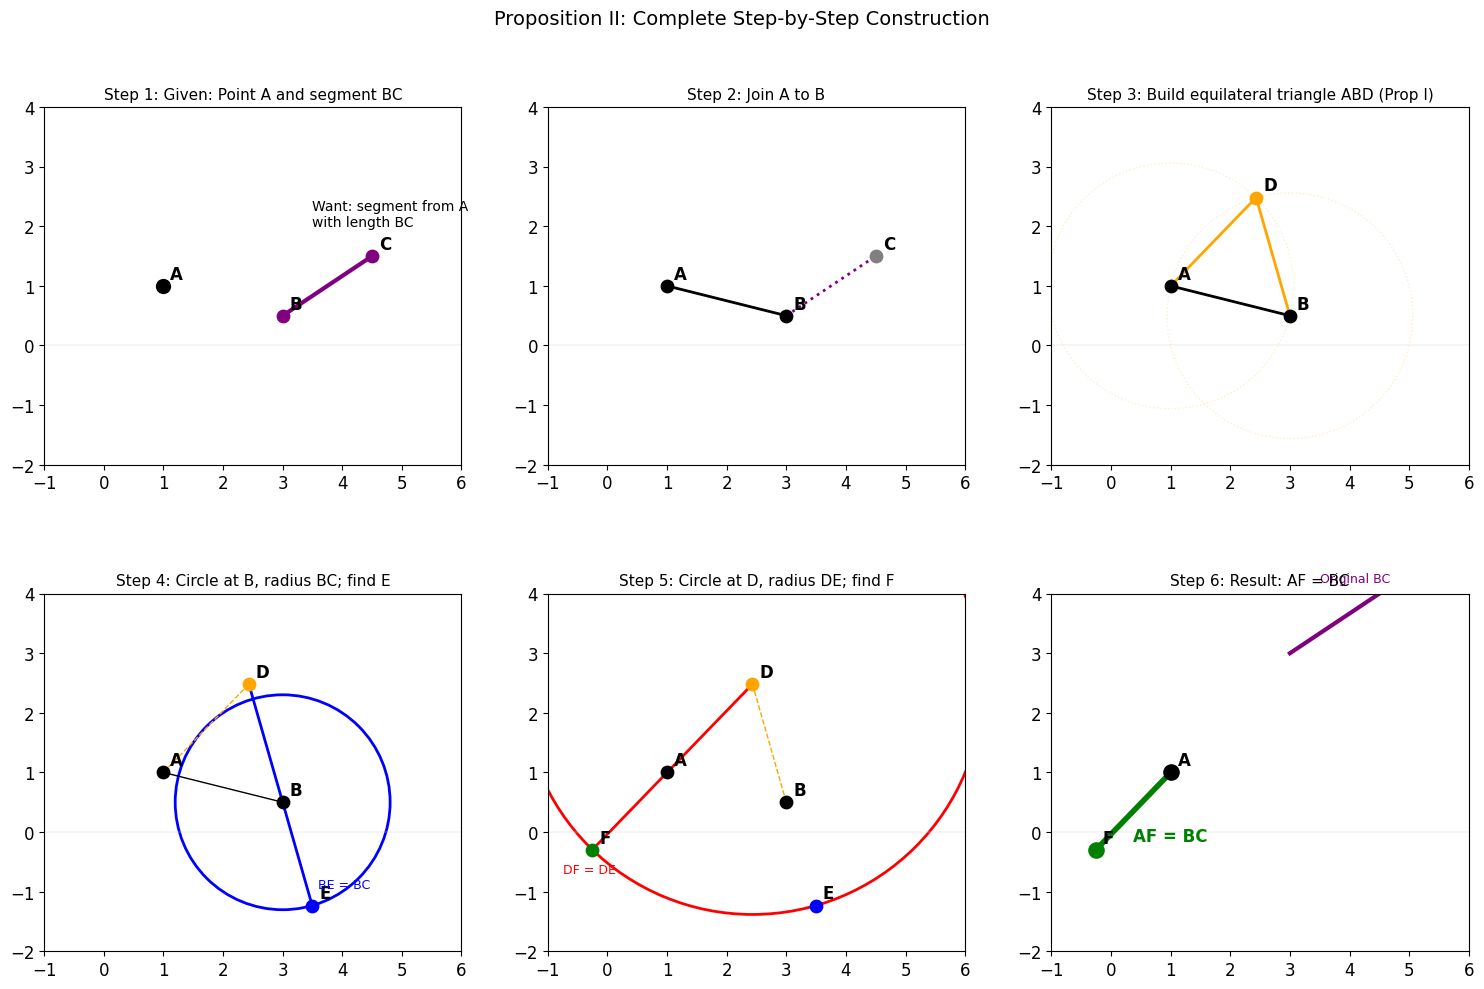

In [7]:
# Interactive Animation: Prop II Step-by-Step
# This shows the complete "distance teleportation" process

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Given: Point A and segment BC
A = np.array([1, 1])
B = np.array([3, 0.5])
C = np.array([4.5, 1.5])
BC_length = np.linalg.norm(C - B)
AB_length = np.linalg.norm(B - A)

# Build equilateral triangle on AB
AB_mid = (A + B) / 2
AB_perp = np.array([-(B-A)[1], (B-A)[0]])
AB_perp = AB_perp / np.linalg.norm(AB_perp)
h_ABD = np.sqrt(AB_length**2 - (AB_length/2)**2)
D = AB_mid + h_ABD * AB_perp

# Find E (extend DB to circle at B)
DB_dir = (B - D) / np.linalg.norm(B - D)
E = B + BC_length * DB_dir

# Find F (extend DA to circle at D)
DE_length = np.linalg.norm(E - D)
DA_dir = (A - D) / np.linalg.norm(A - D)
F = D + DE_length * DA_dir

def setup_ax(ax, title, step):
    ax.set_aspect('equal')
    ax.set_xlim(-1, 6)
    ax.set_ylim(-2, 4)
    ax.set_title(f'Step {step}: {title}', fontsize=11)
    ax.axhline(y=0, color='lightgray', linewidth=0.3)

# Step 1: Given point A and segment BC
ax = axes[0, 0]
setup_ax(ax, 'Given: Point A and segment BC', 1)
draw_point(ax, A, 'A', size=100)
draw_line(ax, B, C, color='purple', linewidth=3)
draw_point(ax, B, 'B', color='purple')
draw_point(ax, C, 'C', color='purple')
ax.text(3.5, 2, 'Want: segment from A\nwith length BC', fontsize=10)

# Step 2: Join A to B
ax = axes[0, 1]
setup_ax(ax, 'Join A to B', 2)
draw_point(ax, A, 'A')
draw_line(ax, B, C, color='purple', linewidth=2, linestyle=':')
draw_point(ax, B, 'B')
draw_point(ax, C, 'C', color='gray')
draw_line(ax, A, B, color='black', linewidth=2)

# Step 3: Build equilateral triangle ABD
ax = axes[0, 2]
setup_ax(ax, 'Build equilateral triangle ABD (Prop I)', 3)
draw_line(ax, A, B, color='black', linewidth=2)
draw_line(ax, A, D, color='orange', linewidth=2)
draw_line(ax, B, D, color='orange', linewidth=2)
draw_point(ax, A, 'A')
draw_point(ax, B, 'B')
draw_point(ax, D, 'D', color='orange')
# Show construction circles faintly
c1 = Circle(A, AB_length, fill=False, color='orange', alpha=0.2, linestyle=':')
c2 = Circle(B, AB_length, fill=False, color='orange', alpha=0.2, linestyle=':')
ax.add_patch(c1)
ax.add_patch(c2)

# Step 4: Circle at B with radius BC
ax = axes[1, 0]
setup_ax(ax, 'Circle at B, radius BC; find E', 4)
draw_line(ax, A, B, color='black', linewidth=1)
draw_line(ax, A, D, color='orange', linewidth=1, linestyle='--')
draw_line(ax, B, D, color='orange', linewidth=1, linestyle='--')
draw_point(ax, A, 'A')
draw_point(ax, B, 'B')
draw_point(ax, D, 'D', color='orange')
# Circle at B
circle_B = Circle(B, BC_length, fill=False, color='blue', linewidth=2)
ax.add_patch(circle_B)
# Extend DB to E
draw_line(ax, D, E, color='blue', linewidth=2)
draw_point(ax, E, 'E', color='blue')
ax.text(E[0]+0.1, E[1]+0.3, 'BE = BC', fontsize=9, color='blue')

# Step 5: Circle at D with radius DE
ax = axes[1, 1]
setup_ax(ax, 'Circle at D, radius DE; find F', 5)
draw_line(ax, A, D, color='orange', linewidth=1, linestyle='--')
draw_line(ax, B, D, color='orange', linewidth=1, linestyle='--')
draw_point(ax, A, 'A')
draw_point(ax, B, 'B')
draw_point(ax, D, 'D', color='orange')
draw_point(ax, E, 'E', color='blue')
# Circle at D
circle_D = Circle(D, DE_length, fill=False, color='red', linewidth=2)
ax.add_patch(circle_D)
# Extend DA to F
draw_line(ax, D, F, color='red', linewidth=2)
draw_point(ax, F, 'F', color='green')
ax.text(F[0]-0.5, F[1]-0.4, 'DF = DE', fontsize=9, color='red')

# Step 6: Result - AF = BC
ax = axes[1, 2]
setup_ax(ax, 'Result: AF = BC', 6)
# Show original BC for comparison
draw_line(ax, B+np.array([0, 2.5]), C+np.array([0, 2.5]), color='purple', linewidth=3)
ax.text(3.5, 4.2, 'Original BC', fontsize=9, color='purple')
# Show AF
draw_line(ax, A, F, color='green', linewidth=4)
draw_point(ax, A, 'A', size=120)
draw_point(ax, F, 'F', color='green', size=120)
ax.text((A[0]+F[0])/2, (A[1]+F[1])/2 - 0.5, f'AF = BC', fontsize=12, color='green', fontweight='bold')

plt.tight_layout()
plt.suptitle('Proposition II: Complete Step-by-Step Construction', fontsize=14, y=1.02)
plt.show()

---

## Proposition IV: Side-Angle-Side (SAS) Congruence

**Statement:** If two triangles have two sides of one equal respectively to two sides of the other, and have the angles included by those sides equal, then the triangles are equal in every respect.

In modern terms: **SAS congruence** — if you know two sides and the included angle match, the whole triangle matches.

---

### The Proof by Superposition

Euclid's proof is beautifully simple: **pick up one triangle and lay it on top of the other.**

Given triangles BAC and EDF where:
- BA = ED
- AC = DF  
- Angle A = Angle D

**Step 1:** Place triangle BAC onto EDF so that:
- Point A lands on point D
- Line AB lies along DE
- Point C is on the same side of DE as F

**Step 2:** Since BA = ED, point B lands exactly on E.

**Step 3:** Since angle BAC = angle EDF, line AC lies along DF.

**Step 4:** Since AC = DF, point C lands exactly on F.

**Step 5:** Now here's the key! We have:
- B coinciding with E
- C coinciding with F

Therefore **BC must coincide with EF**.

Why? Because **"two right lines cannot enclose a space."**

---

### My Insight: This is the Perpendicular Axiom Again!

The phrase "two right lines cannot enclose a space" is just another way of saying:

> **Two points determine exactly one straight line.**

I encountered this same idea in Kiselev's geometry when proving the uniqueness of perpendiculars!

- In Kiselev: There's only ONE straight line from M to N (the perpendicular)
- In Euclid: There's only ONE straight line from B to C (or equivalently, from E to F)

Once we establish that B=E and C=F, there's no freedom left. The line BC MUST be the line EF — they're the same line! There's no "other" straight line that could connect the same two points.

```
If B coincides with E, and C coincides with F:

    B/E ●─────────────────● C/F
    
There's only ONE line connecting these points.
So BC and EF are the same line.
```

This is why Euclid can conclude that the triangles are **equal in every respect**:
- BC = EF (same line)
- Angle B = Angle E (same vertex, same rays)
- Angle C = Angle F (same vertex, same rays)

---

### The Axiom Behind the Proof

Euclid's axiom is essentially:

> Two distinct points determine a unique straight line.

Or equivalently:

> Two straight lines can intersect in at most one point.

If two lines shared two points, they'd "enclose a space" between them at those points — which is impossible for straight lines. They must be the same line.

This fundamental axiom connects to:
1. **Perpendicular uniqueness** (Kiselev) — one straight path from M to N
2. **Triangle congruence** (Euclid) — if endpoints match, lines match
3. **The triangle inequality** (trig) — the straight path is shortest

The same deep truth, appearing in different forms!

---

## Proposition V: Base Angles of an Isosceles Triangle Are Equal

**Statement:** If a triangle has two equal sides (isosceles), then the angles at the base are equal. And if the equal sides are extended beyond the base, the external angles below the base are also equal.

In short: **isosceles triangle → equal base angles.**

---

### What We're Proving

Given triangle ABC where **AB = AC** (isosceles):
- The angles at the base: **angle ABC = angle ACB**
- If we extend AB to D and AC to E, the external angles: **angle DBC = angle ECB**

---

### Euclid's Proof (The "Long Way")

This proof is famously tricky because it involves two triangles that **overlap each other**. Euclid uses Prop III and Prop IV as tools.

**Setup:**
1. On BD (AB extended), pick any point F
2. Use **Prop III** to cut off AG from AE such that **AG = AF**
3. Join BG and CF

Now we have two pairs of triangles to work with.

**First pair — triangles FAC and GAB:**

| Triangle FAC | Triangle GAB |
|---|---|
| FA | GA (= FA by construction) |
| AC | AB (= AC by hypothesis, isosceles) |
| Angle A | Angle A (same angle, common to both) |

By **Prop IV (SAS)**: FC = GB, angle AFC = angle AGB, and **angle ACF = angle ABG**

**Second pair — triangles BFC and CGB:**

Since AF = AG and AB = AC, we get:
- BF = AF - AB = AG - AC = CG

So now triangles BFC and CGB have:

| Triangle BFC | Triangle CGB |
|---|---|
| BF | CG (just proved) |
| FC | GB (just proved from first pair) |
| Angle BFC | Angle CGB (just proved from first pair) |

By **Prop IV (SAS)** again: **angle FBC = angle GCB** (external angles — done!)

And subtracting: angle FCA − angle FCB = angle GBA − angle GBC gives **angle ACB = angle ABC** (base angles — done!)

---

### The Easy Proof: Folding

There's a much slicker proof hidden in the book. It uses the **folding argument** (same as Kiselev's perpendicular proof!):

1. Take triangle ACB and **flip it around the axis AC**
2. It lands in a new position — call it triangle ACD
3. Now triangle BAC and triangle CAD have:
   - BA = AC *(sides of original isosceles triangle)*
   - AC = AD *(same thing after flip)*
   - Angle BAC = Angle CAD *(included angle, preserved by flip)*
4. By **Prop IV (SAS)**: angle ACB = angle ADC
5. But angle ADC = angle ABC *(it's the same angle as before we flipped)*
6. Therefore **angle ACB = angle ABC** ✓

---

### My Insight: Folding as the Deep Reason

The folding proof reveals **why** base angles are equal: an isosceles triangle is **symmetric about its axis of symmetry** (the line from apex to midpoint of base).

This is the same folding argument from Kiselev's perpendicular proof! The fold maps one half onto the other perfectly.

**Axis of symmetry:** A line in a figure such that folding the plane along it causes one half to coincide with the other.

The isosceles triangle has exactly one axis of symmetry — the line from A (apex) down to the midpoint of BC.

```
        A
       / \
      /   \          Fold along the vertical axis:
     /  |  \         Left half maps onto right half
    /   |   \        → Left base angle = Right base angle
   B----+----C
        midpoint
```

---

### Dependency Chain Updated

```
Prop I: Equilateral triangle
    ↓
Prop II: Copy a segment (uses I)
    ↓
Prop III: Cut off a segment (uses II)
    ↓
Prop IV: SAS congruence (uses: two points → one line)
    ↓
Prop V: Isosceles base angles equal (uses III and IV)
```

---

### Corollary

**Every equilateral triangle is equiangular.**

*Proof:* An equilateral triangle is isosceles in three different ways (any two sides are equal). By Prop V, each pair of base angles is equal. So all three angles are equal.

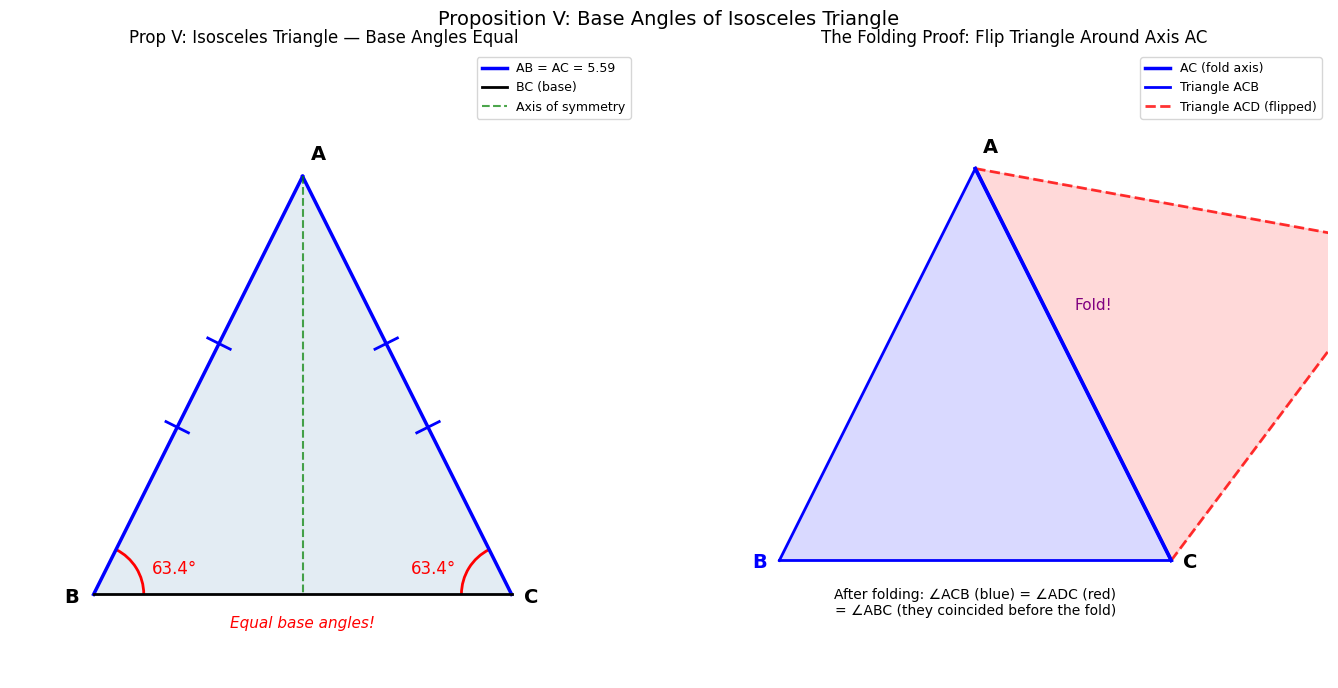

Verification: angle ABC = 63.4349°,  angle ACB = 63.4349°
Equal? True


In [8]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Arc

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

# --- Isosceles triangle ---
A = np.array([2.5, 5])
B = np.array([0, 0])
C = np.array([5, 0])

AB_len = np.linalg.norm(B - A)
AC_len = np.linalg.norm(C - A)

def angle_between(v1, v2):
    cos_a = np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))
    return np.degrees(np.arccos(np.clip(cos_a, -1, 1)))

angle_ABC = angle_between(A - B, C - B)
angle_ACB = angle_between(A - C, B - C)

# LEFT PLOT: Isosceles triangle with base angles
ax = axes[0]
ax.set_aspect('equal')
ax.set_title('Prop V: Isosceles Triangle — Base Angles Equal', fontsize=12)

# Fill triangle
tri = plt.Polygon([A, B, C], alpha=0.15, color='steelblue')
ax.add_patch(tri)

# Draw sides
ax.plot([A[0], B[0]], [A[1], B[1]], 'b-', linewidth=2.5, label=f'AB = AC = {AB_len:.2f}')
ax.plot([A[0], C[0]], [A[1], C[1]], 'b-', linewidth=2.5)
ax.plot([B[0], C[0]], [B[1], C[1]], 'k-', linewidth=2, label='BC (base)')

# Tick marks on equal sides
for t in [0.4, 0.6]:
    p = A + t * (B - A)
    perp = np.array([-(B-A)[1], (B-A)[0]]) / np.linalg.norm(B-A) * 0.15
    ax.plot([p[0]-perp[0], p[0]+perp[0]], [p[1]-perp[1], p[1]+perp[1]], 'b-', linewidth=2)
    p2 = A + t * (C - A)
    perp2 = np.array([-(C-A)[1], (C-A)[0]]) / np.linalg.norm(C-A) * 0.15
    ax.plot([p2[0]-perp2[0], p2[0]+perp2[0]], [p2[1]-perp2[1], p2[1]+perp2[1]], 'b-', linewidth=2)

# Axis of symmetry
mid_BC = (B + C) / 2
ax.plot([A[0], mid_BC[0]], [A[1], mid_BC[1]], 'g--', linewidth=1.5, alpha=0.7, label='Axis of symmetry')

# Angle arcs at B and C
arc_B = Arc(B, 1.2, 1.2, angle=0,
            theta1=0, theta2=angle_ABC, color='red', linewidth=2)
arc_C = Arc(C, 1.2, 1.2, angle=0,
            theta1=180 - angle_ACB, theta2=180, color='red', linewidth=2)
ax.add_patch(arc_B)
ax.add_patch(arc_C)

# Labels
ax.annotate('A', A + np.array([0.1, 0.2]), fontsize=14, fontweight='bold')
ax.annotate('B', B + np.array([-0.35, -0.1]), fontsize=14, fontweight='bold')
ax.annotate('C', C + np.array([0.15, -0.1]), fontsize=14, fontweight='bold')
ax.text(B[0] + 0.7, B[1] + 0.25, f'{angle_ABC:.1f}°', fontsize=12, color='red')
ax.text(C[0] - 1.2, C[1] + 0.25, f'{angle_ACB:.1f}°', fontsize=12, color='red')
ax.text(mid_BC[0], mid_BC[1] - 0.4, 'Equal base angles!', fontsize=11,
        ha='center', color='red', style='italic')

ax.set_xlim(-1, 6.5)
ax.set_ylim(-1, 6.5)
ax.legend(loc='upper right', fontsize=9)
ax.axis('off')

# RIGHT PLOT: The folding proof
ax2 = axes[1]
ax2.set_aspect('equal')
ax2.set_title('The Folding Proof: Flip Triangle Around Axis AC', fontsize=12)

# Original triangle ACB
ax2.plot([A[0], C[0]], [A[1], C[1]], 'b-', linewidth=2.5, label='AC (fold axis)')
ax2.plot([A[0], B[0]], [A[1], B[1]], 'b-', linewidth=2, label='Triangle ACB')
ax2.plot([B[0], C[0]], [B[1], C[1]], 'b-', linewidth=2)

# Mirror B across axis AC to get D
AC_vec = (C - A) / np.linalg.norm(C - A)
AB_proj = np.dot(B - A, AC_vec)
B_proj_pt = A + AB_proj * AC_vec
D = 2 * B_proj_pt - B  # reflect B across AC

# Flipped triangle ACD
ax2.plot([A[0], D[0]], [A[1], D[1]], 'r--', linewidth=2, alpha=0.8, label='Triangle ACD (flipped)')
ax2.plot([C[0], D[0]], [C[1], D[1]], 'r--', linewidth=2, alpha=0.8)
ax2.plot([A[0], C[0]], [A[1], C[1]], 'b-', linewidth=2.5)  # shared axis

# Shade both triangles
tri_orig = plt.Polygon([A, C, B], alpha=0.15, color='blue')
tri_flip = plt.Polygon([A, C, D], alpha=0.15, color='red')
ax2.add_patch(tri_orig)
ax2.add_patch(tri_flip)

# Fold arrow
ax2.annotate('', xy=(D[0], D[1] + 0.3), xytext=(B[0], B[1] + 0.3),
             arrowprops=dict(arrowstyle='->', color='purple', lw=1.5,
                             connectionstyle='arc3,rad=-0.3'))
ax2.text((B[0]+D[0])/2, (B[1]+D[1])/2 + 1.2, 'Fold!', fontsize=11, color='purple', ha='center')

ax2.annotate('A', A + np.array([0.1, 0.2]), fontsize=14, fontweight='bold')
ax2.annotate('B', B + np.array([-0.35, -0.1]), fontsize=14, color='blue', fontweight='bold')
ax2.annotate('C', C + np.array([0.15, -0.1]), fontsize=14, fontweight='bold')
ax2.annotate('D', D + np.array([0.15, -0.1]), fontsize=14, color='red', fontweight='bold')

ax2.text(2.5, -0.7,
         'After folding: ∠ACB (blue) = ∠ADC (red)\n= ∠ABC (they coincided before the fold)',
         fontsize=10, ha='center')

ax2.set_xlim(-1, 7)
ax2.set_ylim(-1.5, 6.5)
ax2.legend(loc='upper right', fontsize=9)
ax2.axis('off')

plt.suptitle('Proposition V: Base Angles of Isosceles Triangle', fontsize=14)
plt.tight_layout()
plt.show()

print(f"Verification: angle ABC = {angle_ABC:.4f}°,  angle ACB = {angle_ACB:.4f}°")
print(f"Equal? {np.isclose(angle_ABC, angle_ACB)}")

---

## Proposition VI: Equal Base Angles → Equal Sides (Converse of Prop V)

**Statement:** If a triangle has two equal base angles, then the sides opposite those angles are also equal.

In short: **equal base angles → isosceles triangle.**

---

### Intuition: Symmetry Forces Equality

Before the formal proof, think physically.

Lay down a flat base $BC$. At each end, tilt a line upward at the **exact same angle**. Because both lines climb at the same rate, they must rise symmetrically and meet at a point $A$ directly above the midpoint of $BC$. The distance each line travels to reach $A$ is necessarily identical.

If one side were longer, the apex would lean toward one side, which would immediately destroy the symmetry of the angles at the base. Equal angles *force* equal sides.

---

### Proof by Contradiction (Reductio ad Absurdum)

Euclid cannot yet use "symmetry" as a rigorous tool, so he proves it by showing that the opposite assumption leads to an impossible absurdity.

**Given:** Triangle $ABC$ with $\angle ABC = \angle ACB$.

**Goal:** Prove $AB = AC$.

**Step 1 — The assumption.**

Assume $AB \neq AC$. Then one must be longer. Without loss of generality, assume $AB > AC$.

**Step 2 — The construction.**

If $AB > AC$, we can mark a point $D$ on segment $AB$ (between $B$ and $A$) such that:
$$DB = AC$$
Connect $D$ to $C$. We now have a new, smaller triangle $\triangle DBC$ nested inside $\triangle ACB$.

**Step 3 — Apply Prop IV (SAS).**

Compare $\triangle DBC$ with $\triangle ACB$:

| $\triangle DBC$ | $\triangle ACB$ |
|---|---|
| $DB$ | $AC$ — equal by construction |
| $BC$ | $BC$ — same shared base |
| $\angle DBC$ | $\angle ACB$ — equal by hypothesis (the given base angles) |

Two sides and the included angle are equal. By **Proposition IV (SAS)**, the two triangles are congruent:
$$\triangle DBC \cong \triangle ACB$$

**Step 4 — The absurdity.**

Congruent triangles have equal area:
$$\text{Area}(\triangle DBC) = \text{Area}(\triangle ACB)$$

But $\triangle DBC$ is a **proper part** of $\triangle ACB$ — it sits strictly inside the larger triangle ($D$ is between $B$ and $A$, so $\triangle DBC$ is missing the region $\triangle DAC$ from the top).

This violates **Euclid's Common Notion 5:** *"The whole is greater than the part."*

**Step 5 — Conclusion.**

The assumption that $AB > AC$ leads to a contradiction. By symmetric reasoning, $AB < AC$ also leads to a contradiction. Therefore:
$$AB = AC \qquad \blacksquare$$

---

### Why this is beautiful

Instead of measuring sides directly, Euclid shows that *any universe where angles are equal but sides differ* is a universe where a piece of a triangle equals the whole triangle. By eliminating the impossible, only the truth survives.

---

### Dependency Chain Updated

```
Prop I: Equilateral triangle
    ↓
Prop II: Copy a segment (uses I)
    ↓
Prop III: Cut off a segment (uses II)
    ↓
Prop IV: SAS congruence
    ↓
Prop V: Isosceles base angles equal (uses III + IV)
    ↓
Prop VI: Equal base angles → equal sides  ← converse of V
         (uses IV + Common Notion 5)
```

**Note:** Prop VI is the converse of Prop V, but it requires a completely different proof technique (contradiction instead of direct construction).


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Arc

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

# ── Triangle ABC — symmetric so ∠B = ∠C exactly ──────────────────────────────
A = np.array([2.5, 4.5])
B = np.array([0.0, 0.0])
C = np.array([5.0, 0.0])

AB_length = np.linalg.norm(B - A)
AC_length = np.linalg.norm(C - A)

def angle_between(v1, v2):
    cos_a = np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))
    return np.degrees(np.arccos(np.clip(cos_a, -1, 1)))

angle_B = angle_between(A - B, C - B)
angle_C = angle_between(A - C, B - C)

# D on AB at 75% of the way from B toward A
# (hypothetical: we're assuming AB > AC and cutting off DB = AC from AB)
D_frac = 0.75
D = B + D_frac * (A - B)
DB_len = np.linalg.norm(D - B)

# ── LEFT PLOT: The Setup ────────────────────────────────────────────────────
ax = axes[0]
ax.set_aspect('equal')
ax.set_title('Prop VI — Setup\n∠B = ∠C (given).  Assume AB > AC: mark D on AB with DB = AC.',
             fontsize=10.5)

# Big triangle ACB (light fill)
ax.fill(*zip(A, B, C), alpha=0.10, color='steelblue')
ax.plot([A[0], B[0]], [A[1], B[1]], 'b-', lw=2.5, label=f'AB (assumed longer, ≈{AB_length:.2f})')
ax.plot([A[0], C[0]], [A[1], C[1]], 'g-', lw=2.5, label=f'AC (shorter side, ≈{AC_length:.2f})')
ax.plot([B[0], C[0]], [B[1], C[1]], 'k-', lw=2.5, label='BC (shared base)')

# D on AB and the new line DC
ax.plot(*D, 'ro', ms=9, zorder=5)
ax.plot([D[0], B[0]], [D[1], B[1]], 'r-', lw=3.0, label=f'DB = AC (cut)')
ax.plot([D[0], C[0]], [D[1], C[1]], 'r--', lw=2.0, label='DC (new segment)')

# Angle arcs at B and C (the given equal angles)
arc_B = Arc(B, 1.3, 1.3, angle=0, theta1=0, theta2=angle_B, color='purple', lw=2.5)
arc_C = Arc(C, 1.3, 1.3, angle=0, theta1=180 - angle_C, theta2=180, color='purple', lw=2.5)
ax.add_patch(arc_B)
ax.add_patch(arc_C)
ax.text(B[0] + 0.75, B[1] + 0.30, '∠B', fontsize=13, color='purple', fontweight='bold')
ax.text(C[0] - 1.1,  C[1] + 0.30, '∠C', fontsize=13, color='purple', fontweight='bold')
ax.text(2.5, 0.28, '∠B = ∠C  (given)', ha='center', fontsize=10, color='purple',
        bbox=dict(fc='lavender', ec='purple', boxstyle='round,pad=0.3'))

# Tick marks on DB = AC
for t in [0.3, 0.7]:
    p  = B + t * (D - B)
    pv = np.array([-(D - B)[1], (D - B)[0]]) / np.linalg.norm(D - B) * 0.12
    ax.plot([p[0]-pv[0], p[0]+pv[0]], [p[1]-pv[1], p[1]+pv[1]], 'r-', lw=2)
    q  = A + t * (C - A)
    qv = np.array([-(C - A)[1], (C - A)[0]]) / np.linalg.norm(C - A) * 0.12
    ax.plot([q[0]-qv[0], q[0]+qv[0]], [q[1]-qv[1], q[1]+qv[1]], 'g-', lw=2)

# Point labels
ax.text(A[0] + 0.1, A[1] + 0.2, 'A', fontsize=14, fontweight='bold')
ax.text(B[0] - 0.38, B[1] - 0.1, 'B', fontsize=14, fontweight='bold')
ax.text(C[0] + 0.15, C[1] - 0.1, 'C', fontsize=14, fontweight='bold')
ax.text(D[0] - 0.40, D[1] + 0.10, 'D', fontsize=14, color='red', fontweight='bold')

ax.set_xlim(-1, 7); ax.set_ylim(-0.8, 6)
ax.legend(loc='upper right', fontsize=9)
ax.axis('off')

# ── RIGHT PLOT: The Absurdity ───────────────────────────────────────────────
ax2 = axes[1]
ax2.set_aspect('equal')
ax2.set_title('The Contradiction\n△DBC ≅ △ACB  (SAS)  but  △DBC ⊊ △ACB', fontsize=10.5)

# Full triangle ACB — blue, lightly filled
ax2.fill(*zip(A, B, C), alpha=0.18, color='steelblue', label='△ACB  (the whole triangle)')
ax2.plot([A[0], B[0]], [A[1], B[1]], 'b-', lw=2.5)
ax2.plot([A[0], C[0]], [A[1], C[1]], 'b-', lw=2.5)
ax2.plot([B[0], C[0]], [B[1], C[1]], 'b-', lw=2.5)

# Nested triangle DBC — red, more opaque
ax2.fill(*zip(D, B, C), alpha=0.38, color='tomato', label='△DBC  (the smaller, nested triangle)')
ax2.plot([D[0], B[0]], [D[1], B[1]], 'r-', lw=3.0)
ax2.plot([D[0], C[0]], [D[1], C[1]], 'r-', lw=3.0)
ax2.plot([B[0], C[0]], [B[1], C[1]], 'r-', lw=2.0)

# Shade the "extra" region inside ACB but outside DBC
extra_region = plt.Polygon([A, D, C], alpha=0.20, color='steelblue')
ax2.add_patch(extra_region)
ax2.text(2.5 + 0.5, 3.5, '△ADC\n(extra\nregion)', ha='center', fontsize=9,
         color='steelblue', style='italic')

# SAS reasoning box
sas_box = ("SAS argument:\n"
           "  DB  =  AC          (construction)\n"
           "  BC  =  BC          (shared base)\n"
           "  ∠DBC = ∠ACB    (given ∠B = ∠C)\n"
           "→  △DBC ≅ △ACB")
ax2.text(2.5, 5.6, sas_box, ha='center', va='center', fontsize=9.5,
         bbox=dict(fc='#fff3cd', ec='#e6a817', boxstyle='round,pad=0.5'))

# The absurdity note at the bottom
ax2.text(2.5, -0.55,
         'Area(△DBC) = Area(△ACB)  — from congruence\n'
         'But D is between B and A, so △DBC is strictly inside △ACB\n'
         '"The whole is greater than the part."  — Common Notion 5\n'
         '→ Contradiction!  The assumption AB > AC must be FALSE.',
         ha='center', va='top', fontsize=9.5,
         bbox=dict(fc='#f8d7da', ec='#dc3545', boxstyle='round,pad=0.45'))

# Point labels
ax2.text(A[0] + 0.1, A[1] + 0.2, 'A', fontsize=14, fontweight='bold', color='steelblue')
ax2.text(B[0] - 0.38, B[1] - 0.1, 'B', fontsize=14, fontweight='bold')
ax2.text(C[0] + 0.15, C[1] - 0.1, 'C', fontsize=14, fontweight='bold')
ax2.text(D[0] - 0.40, D[1] + 0.10, 'D', fontsize=14, color='red', fontweight='bold')

ax2.set_xlim(-1, 7); ax2.set_ylim(-1.6, 6.5)
ax2.legend(loc='lower left', fontsize=9.5)
ax2.axis('off')

plt.suptitle('Proposition VI: Equal Base Angles → Equal Sides  (Converse of Prop V)',
             fontsize=14)
plt.tight_layout()
plt.show()

print("Triangle setup:")
print(f"  AB = {AB_length:.4f},   AC = {AC_length:.4f}  (equal — it's symmetric)")
print(f"  ∠B = {angle_B:.4f}°,   ∠C = {angle_C:.4f}°  (equal — confirmed)")
print(f"\nHypothetical D at {D_frac*100:.0f}% of AB from B:")
print(f"  DB = {DB_len:.4f}  (this equals AC in the actual proof)")
print(f"\nConclusion: assuming AB ≠ AC leads to 'Area(part) = Area(whole)' → impossible.")
print("Therefore AB = AC.  □")
